In [2]:
import pandas as pd 
import numpy as np
import os
import joblib
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt



In [25]:
from pathlib import Path

# 1️⃣ Try current notebook folder
try:
    NOTEBOOK_DIR = Path.cwd()  # current working folder
except FileNotFoundError:
    # 2️⃣ Fallback to your repo in Documents
    NOTEBOOK_DIR = Path.home() / "Documents/invesment-portfolio-analysis"

# 3️⃣ Repo root (adjust based on your folder structure)
REPO_ROOT = NOTEBOOK_DIR  # if notebook is in repo root
# Or, if notebook is inside a subfolder, e.g., notebooks/, use:
# REPO_ROOT = NOTEBOOK_DIR.parent  

# 4️⃣ Input/output paths
INPUT_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "processed"
OUTPUT_FILE = OUTPUT_DIR / "master_top_companies.csv"

# 5️⃣ Create processed folder if missing
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 6️⃣ Collect CSV files safely
all_dfs = []
if INPUT_DIR.exists():
    csv_files = sorted([p for p in INPUT_DIR.iterdir() if p.suffix.lower() == ".csv"])
    print(f"Found {len(csv_files)} CSV files in {INPUT_DIR}")
else:
    csv_files = []
    print(f"⚠ Input folder {INPUT_DIR} does not exist!")

# Now you can read the CSVs
for file in csv_files:
    df = pd.read_csv(file)
    all_dfs.append(df)


Found 49 CSV files in /Users/ishanlahiru/Documents/invesment-portfolio-analysis/data


In [26]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_dfs = []
csv_files = sorted([p for p in INPUT_DIR.iterdir() if p.suffix.lower() == ".csv"])

if not csv_files:
    print(f"No CSV files found in {INPUT_DIR}")
else:
    for file_path in csv_files:
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"Failed to read {file_path.name}: {e}")
            continue

        if df.empty:
            print(f" Skipping empty CSV: {file_path.name}")
            continue

        # If date column exists, parse it now
        if "lastTradedTime" in df.columns:
            df["lastTradedTime"] = pd.to_datetime(df["lastTradedTime"], errors="coerce")
            df = df.dropna(subset=["lastTradedTime"])  # remove invalid dates

        all_dfs.append(df)

    if not all_dfs:
        print(" No valid data to combine.")
    else:
        master_df = pd.concat(all_dfs, ignore_index=True)

        # If lastTradedTime column present, filter by date range
        if "lastTradedTime" in master_df.columns:
            START_DATE = pd.to_datetime("2023-01-01")
            END_DATE = pd.to_datetime("2025-09-23")
            master_df = master_df[(master_df["lastTradedTime"] >= START_DATE) & 
                                  (master_df["lastTradedTime"] <= END_DATE)]

            master_df.sort_values(by="lastTradedTime", inplace=True)
            master_df.reset_index(drop=True, inplace=True)

        # Drop columns if exist
        cols_to_drop = ["crossingTradeVol", "crossingVolume", "marketCapPercentage", "quantity", "status"]
        master_df = master_df.drop(columns=[c for c in cols_to_drop if c in master_df.columns])

        # Clean strings: strip whitespace, replace empty strings/NaN with "null"
        # First, convert non-datetime columns to string safely
        for col in master_df.columns:
            if pd.api.types.is_datetime64_any_dtype(master_df[col]):
                continue  # keep datetimes if any
            master_df[col] = master_df[col].astype(str).apply(lambda x: x.strip() if isinstance(x, str) else x)
            master_df[col] = master_df[col].replace({"": "null", "nan": "null", "None": "null"})
        master_df = master_df.fillna("null")

        # If you prefer datetimes saved as ISO strings, convert datetime column to string
        if "lastTradedTime" in master_df.columns and pd.api.types.is_datetime64_any_dtype(master_df["lastTradedTime"]):
            master_df["lastTradedTime"] = master_df["lastTradedTime"].dt.strftime("%Y-%m-%dT%H:%M:%S")

        master_df.to_csv(OUTPUT_FILE, index=False)
        print(f" Final cleaned CSV saved at: {OUTPUT_FILE}")
        print(f" rows: {len(master_df)}, columns: {len(master_df.columns)}")
        print(f" Remaining columns: {list(master_df.columns)}")
# ---------- end cell ----------


 Skipping empty CSV: Royal_Dutch_Shell.csv
 Final cleaned CSV saved at: /Users/ishanlahiru/Documents/invesment-portfolio-analysis/processed/master_top_companies.csv
 rows: 32784, columns: 16
 Remaining columns: ['id', 'name', 'symbol', 'percentageChange', 'change', 'price', 'previousClose', 'high', 'low', 'turnover', 'sharevolume', 'tradevolume', 'marketCap', 'open', 'closingPrice', 'lastTradedTime']


In [27]:
master_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32784 entries, 0 to 32783
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                32784 non-null  object
 1   name              32784 non-null  object
 2   symbol            32784 non-null  object
 3   percentageChange  32784 non-null  object
 4   change            32784 non-null  object
 5   price             32784 non-null  object
 6   previousClose     32784 non-null  object
 7   high              32784 non-null  object
 8   low               32784 non-null  object
 9   turnover          32784 non-null  object
 10  sharevolume       32784 non-null  object
 11  tradevolume       32784 non-null  object
 12  marketCap         32784 non-null  object
 13  open              32784 non-null  object
 14  closingPrice      32784 non-null  object
 15  lastTradedTime    32784 non-null  object
dtypes: object(16)
memory usage: 4.0+ MB


In [6]:
master_df.describe()




,id,name,symbol,percentageChange,change,price,previousClose,high,low,turnover,sharevolume,tradevolume,marketCap,open,closingPrice,lastTradedTime
count,32784,32784,32784,32784,32784,32784,32784,32784,32784,32784,32784,32784,32784,32784,32784,32784
unique,683,48,48,32478,7480,22815,22794,22806,22836,32784,30815,30815,48,22206,22815,683
top,1,ASML Holding,ASML,0.0,0.0,63.84000015258789,null,165.0,62.58000183105469,371014711.9445801,3008200,3008200,380375662592,173.0,63.84000015258789,2023-01-03T00:00:00
freq,48,683,683,161,161,9,48,9,9,1,4,4,683,13,9,48


In [9]:
# Count of columns with any missing values
num_cols_with_na = (master_df.isnull().sum() > 0).sum()
print("Columns with at least one missing value:", num_cols_with_na)


Columns with at least one missing value: 0


In [7]:
FEATURE_FILE = OUTPUT_DIR / "newfeatures_optimized.csv"
MASTER_FILE = OUTPUT_DIR / "master_top_companies.csv"
# --- Load the cleaned data ---
master_df = pd.read_csv(MASTER_FILE)

In [ ]:
# --- Convert data types ---
master_df['lastTradedTime'] = pd.to_datetime(master_df['lastTradedTime'], errors='coerce')
num_cols = ['price','high','low','previousClose','turnover','sharevolume','tradevolume','marketCap','change','percentageChange','open','closingPrice']
for col in num_cols:
    if col in master_df.columns:
        master_df[col] = pd.to_numeric(master_df[col], errors='coerce')

master_df = master_df.sort_values(['symbol','lastTradedTime']).reset_index(drop=True)
grouped = master_df.groupby('symbol')

# --- Core returns & volatility ---
master_df['log_return_1d'] = grouped['price'].transform(lambda x: np.log(x / x.shift(1)))
for w in [5,10,20]:
    master_df[f'log_return_{w}d'] = grouped['price'].transform(lambda x: np.log(x / x.shift(w)))
    master_df[f'price_sma_{w}'] = grouped['price'].transform(lambda x: x.rolling(w).mean())
    master_df[f'price_std_{w}'] = grouped['price'].transform(lambda x: x.rolling(w).std())
    master_df[f'volatility_{w}d'] = grouped['log_return_1d'].transform(lambda x: x.rolling(w).std())

# --- Momentum & ratios ---
master_df['momentum_10'] = grouped['price'].transform(lambda x: x / x.shift(10) - 1)
master_df['volatility_ratio'] = master_df['price_std_10'] / (master_df['price_std_20'] + 1e-9)
master_df['price_over_sma20'] = master_df['price'] / (master_df['price_sma_20'] + 1e-9) - 1

# --- Volume indicators (using sharevolume) ---
master_df['volume_sma_5'] = grouped['sharevolume'].transform(lambda x: x.rolling(5).mean())
master_df['volume_ratio'] = master_df['sharevolume'] / (master_df['volume_sma_5'] + 1e-9)

# --- MACD ---
master_df['ema_12'] = grouped['price'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
master_df['ema_26'] = grouped['price'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
master_df['macd'] = master_df['ema_12'] - master_df['ema_26']
master_df['macd_signal'] = grouped['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
master_df['macd_hist'] = master_df['macd'] - master_df['macd_signal']

# --- Bollinger Bands ---
for w in [20]:
    mean = grouped['price'].transform(lambda x: x.rolling(w).mean())
    std = grouped['price'].transform(lambda x: x.rolling(w).std())
    master_df[f'bb_upper_{w}'] = mean + 2*std
    master_df[f'bb_lower_{w}'] = mean - 2*std
    master_df[f'bb_width_{w}'] = 4*std
    master_df[f'bb_percent_b_{w}'] = (master_df['price'] - (mean - 2*std)) / (4*std + 1e-9)

# --- ATR & RSI ---
master_df['tr'] = np.maximum(
    master_df['high'] - master_df['low'],
    np.abs(master_df['high'] - master_df['previousClose']),
    np.abs(master_df['low'] - master_df['previousClose'])
)
master_df['atr_14'] = grouped['tr'].transform(lambda x: x.rolling(14).mean())

def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

master_df['rsi_14'] = grouped['price'].transform(lambda x: compute_rsi(x))

# --- Regime & liquidity ---
master_df['rolling_max_60'] = grouped['price'].transform(lambda x: x.rolling(60).max())
master_df['drawdown_60'] = (master_df['price'] - master_df['rolling_max_60']) / (master_df['rolling_max_60'] + 1e-9)
master_df['turnover_mktcap'] = master_df['turnover'] / (master_df['marketCap'] + 1e-9)

# --- Cyclic time features ---
master_df['day_of_week'] = master_df['lastTradedTime'].dt.dayofweek
master_df['month'] = master_df['lastTradedTime'].dt.month
master_df['day_of_week_sin'] = np.sin(2*np.pi*master_df['day_of_week']/7)
master_df['day_of_week_cos'] = np.cos(2*np.pi*master_df['day_of_week']/7)
master_df['month_sin'] = np.sin(2*np.pi*master_df['month']/12)
master_df['month_cos'] = np.cos(2*np.pi*master_df['month']/12)

# --- Cross-sectional z-scores ---
for col in ['price','log_return_1d','volume_ratio']:
    if col in master_df.columns:
        master_df[f'{col}_zscore_xsec'] = master_df.groupby('lastTradedTime')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9)
        )

# --- Lag features ---
for lag in [1,5]:
    master_df[f'log_return_lag_{lag}'] = grouped['log_return_1d'].transform(lambda x: x.shift(lag))

# --- Target variable ---
master_df['y_10d_log_return'] = grouped['price'].transform(lambda x: np.log(x.shift(-10) / x))
master_df['y_10d_price'] = grouped['price'].transform(lambda x: x.shift(-10))

# --- Final cleanup ---
master_df.dropna(subset=['y_10d_price'], inplace=True)
master_df.reset_index(drop=True, inplace=True)

# --- Save final feature set ---
master_df.to_csv(FEATURE_FILE, index=False)
print(f" Advanced optimized feature set saved: {FEATURE_FILE}")
print(f"Rows: {len(master_df)}, Columns: {len(master_df.columns)}")

✅ Advanced optimized feature set saved: /Users/ishanlahiru/Documents/invesment-portfolio-analysis/processed/newfeatures_optimized.csv
Rows: 32304, Columns: 62


In [9]:


print("Reading:", FEATURE_FILE)
df = pd.read_csv(FEATURE_FILE)


df = df.dropna(subset=['y_10d_price']).reset_index(drop=True)


LOOKBACK_MAX = 60

def trim_group(g: pd.DataFrame) -> pd.DataFrame:
   
    return g.iloc[LOOKBACK_MAX:]

df = df.groupby('symbol', group_keys=False).apply(trim_group).reset_index(drop=True)


protected_cols = ['y_10d_price', 'y_10d_log_return']
feature_cols = df.columns.difference(protected_cols)


num_feature_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

df[num_feature_cols] = (
    df.groupby('symbol')[num_feature_cols]
      .apply(lambda g: g.ffill().bfill())
      .reset_index(level=0, drop=True)
)



remaining_na_cols = df.columns[df.isnull().any()].tolist()
if remaining_na_cols:
    for col in remaining_na_cols:
        if col in protected_cols:
            continue
        
        df[col] = (
            df.groupby('symbol')[col]
              .apply(lambda g: g.fillna(g.median()))
              .reset_index(level=0, drop=True)
        )


assert df['y_10d_price'].notna().all(), "Target has NaNs after cleanup!"
num_cols_check = df.select_dtypes(include=[np.number]).columns
assert not df[num_cols_check].isnull().any().any(), "Numeric features still have NaNs!"


df.to_csv(FEATURE_FILE, index=False)
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print("Missing values per column after cleanup:")
print(df.isnull().sum().to_string())


Reading: /Users/ishanlahiru/Documents/invesment-portfolio-analysis/processed/newfeatures_optimized.csv


/var/folders/d5/p58vb38175d8xw9s73_rl4g00000gn/T/ipykernel_44595/885224652.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('symbol', group_keys=False).apply(trim_group).reset_index(drop=True)


Rows: 29424, Columns: 62
Missing values per column after cleanup:
id                           0
name                         0
symbol                       0
percentageChange             0
change                       0
price                        0
previousClose                0
high                         0
low                          0
turnover                     0
sharevolume                  0
tradevolume                  0
marketCap                    0
open                         0
closingPrice                 0
lastTradedTime               0
log_return_1d                0
log_return_5d                0
price_sma_5                  0
price_std_5                  0
volatility_5d                0
log_return_10d               0
price_sma_10                 0
price_std_10                 0
volatility_10d               0
log_return_20d               0
price_sma_20                 0
price_std_20                 0
volatility_20d               0
momentum_10                  0
vola

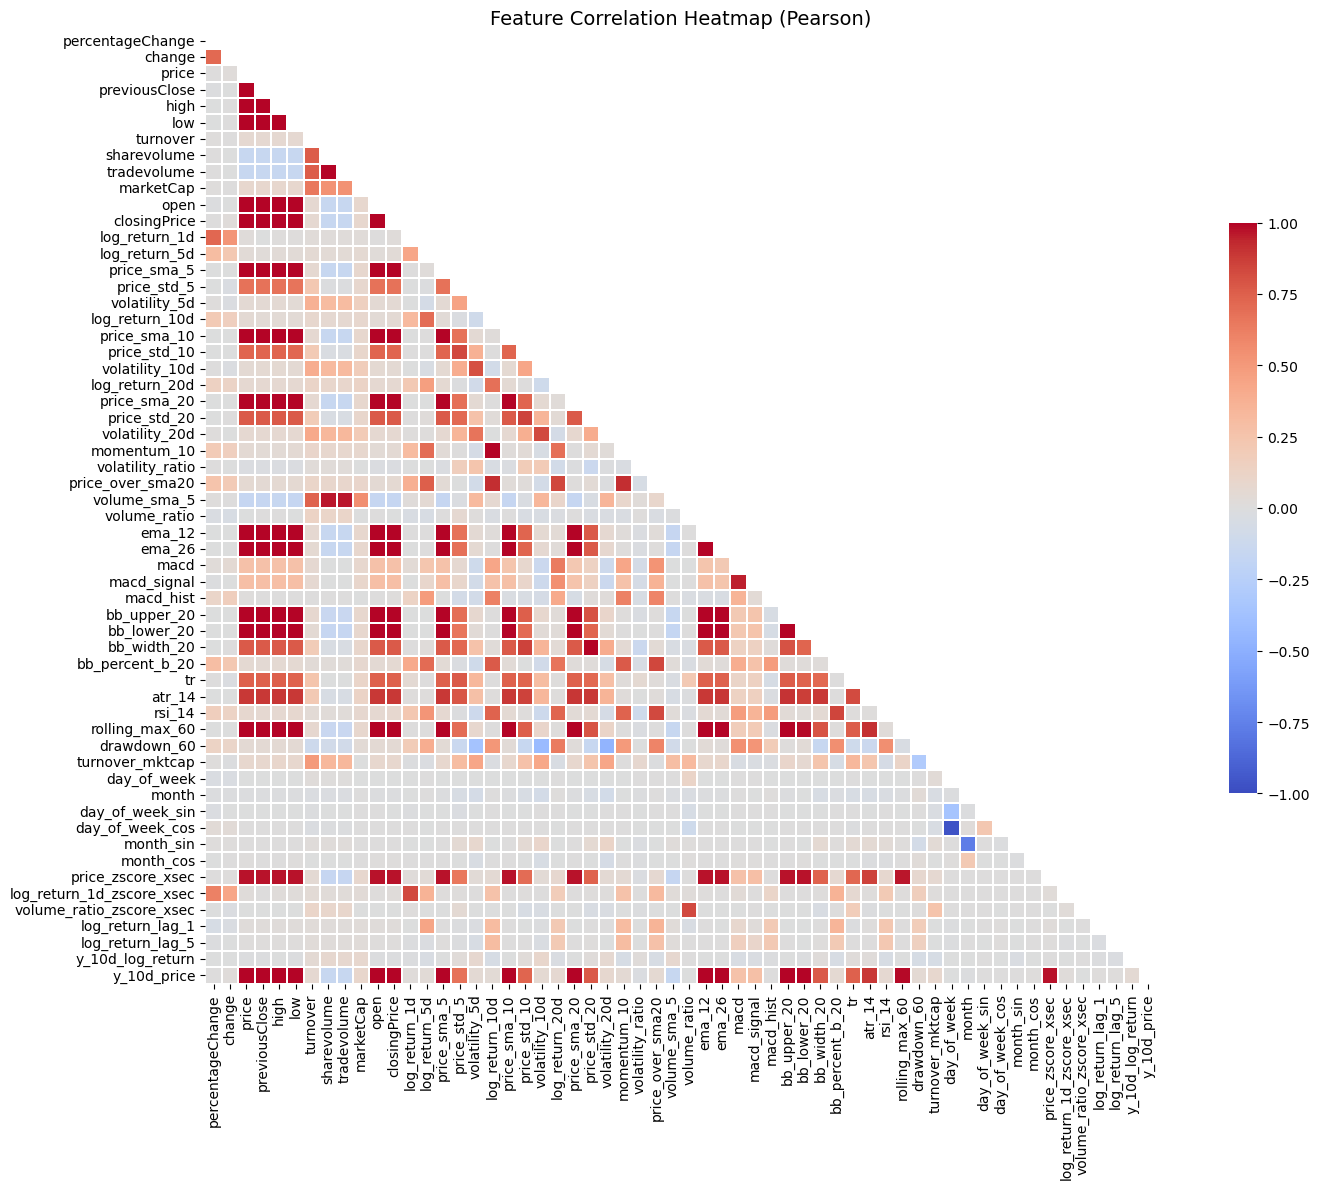

In [10]:


target = 'y_10d_price'  
exclude = ['id','name','symbol','lastTradedTime']
num_df = df.drop(columns=[c for c in exclude if c in df.columns], errors='ignore')
num_df = num_df.select_dtypes(include=[np.number])


corr_cols = num_df.columns.tolist()


corr = num_df[corr_cols].corr(method='pearson')

mask = np.triu(np.ones_like(corr, dtype=bool))


plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.6},
)
plt.title('Feature Correlation Heatmap (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()


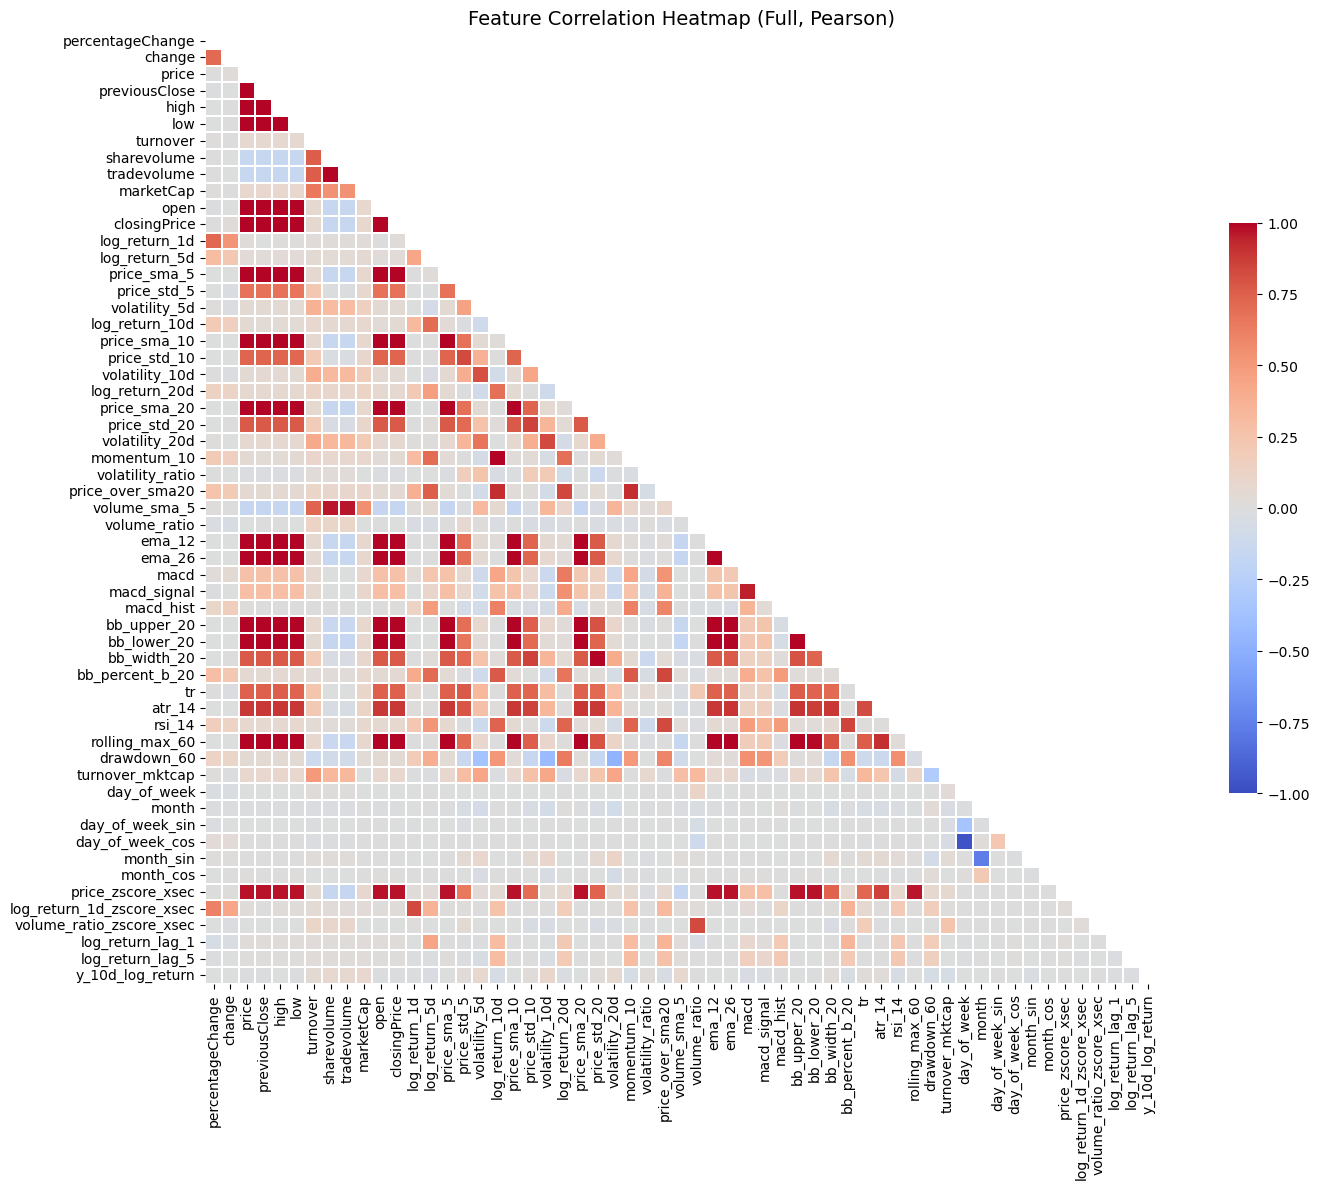

Selected 21 features (threshold=0.92, topN=40):
['ema_12', 'momentum_10', 'atr_14', 'volume_sma_5', 'log_return_lag_1', 'month_cos', 'tr', 'price_std_10', 'price_std_5', 'macd_signal', 'marketCap', 'turnover_mktcap', 'rsi_14', 'turnover', 'log_return_20d', 'volatility_10d', 'price_over_sma20', 'bb_percent_b_20', 'y_10d_log_return', 'volatility_5d', 'drawdown_60']

|corr(target)| of selected features:
ema_12              0.995481
atr_14              0.888216
tr                  0.746712
price_std_10        0.728292
price_std_5         0.675062
macd_signal         0.276508
volume_sma_5        0.154772
marketCap           0.087339
turnover_mktcap     0.080236
rsi_14              0.069215
turnover            0.066672
log_return_20d      0.066334
volatility_10d      0.059235
price_over_sma20    0.056731
bb_percent_b_20     0.055520
y_10d_log_return    0.054121
volatility_5d       0.050527
drawdown_60         0.049920
momentum_10         0.046888
log_return_lag_1    0.015392
month_cos       

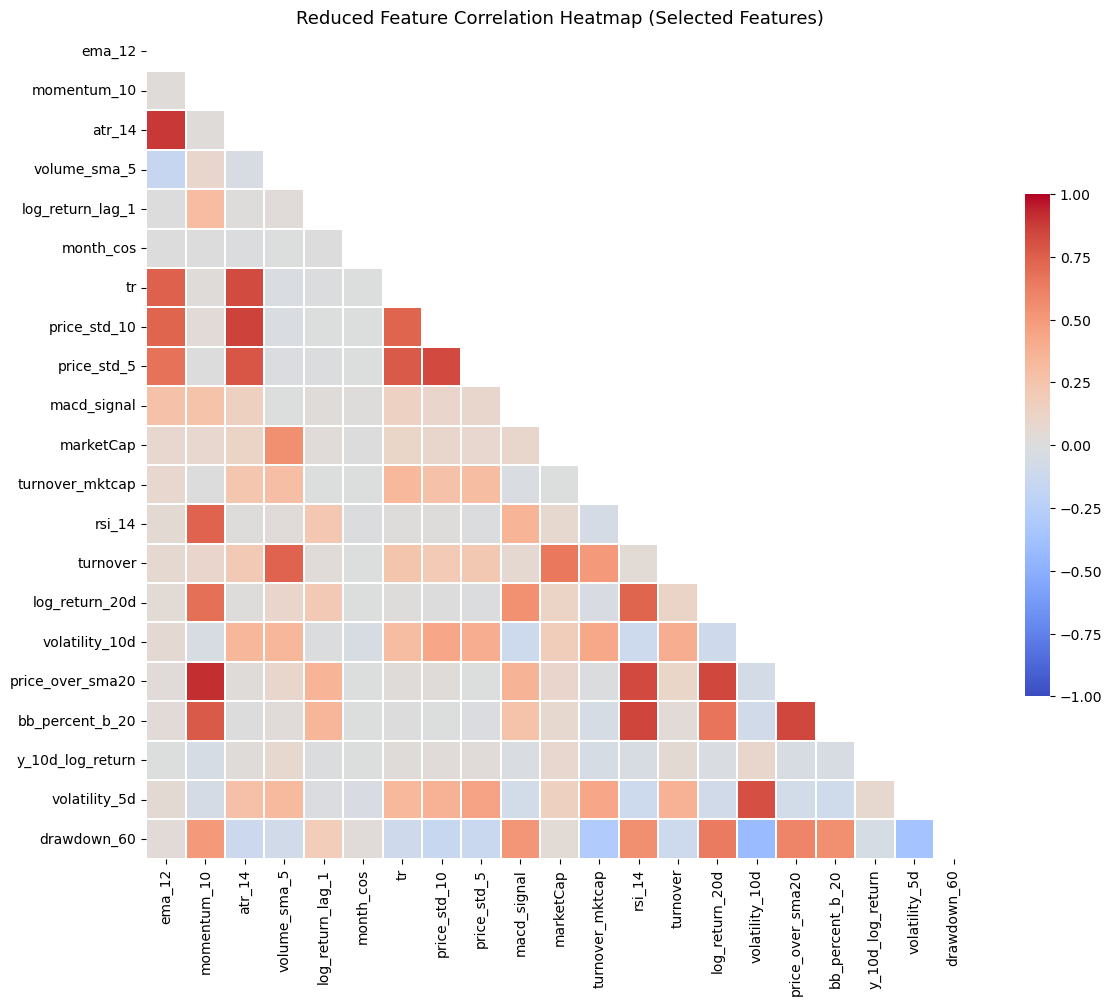

In [19]:

target = 'y_10d_price'          
exclude = ['id','name','symbol','lastTradedTime', target]
corr_threshold = 0.92            
topN_primary = 40                
keep_min_corr = 0.02            
max_features = 35                



num_df = df.drop(columns=[c for c in exclude if c in df.columns], errors='ignore')
num_df = num_df.select_dtypes(include=[np.number])


corr_full = num_df.corr(method='pearson')


plt.figure(figsize=(16, 12))
mask_full = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(
    corr_full, mask=mask_full, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, cbar_kws={'shrink': 0.6}
)
plt.title('Feature Correlation Heatmap (Full, Pearson)', fontsize=14)
plt.tight_layout()
plt.show()


corr_to_target = num_df.corrwith(df[target])
abs_corr = corr_to_target.abs().sort_values(ascending=False)


ranked = abs_corr[abs_corr >= keep_min_corr].index.tolist()
ranked = ranked[:topN_primary]


orthogonal_groups = {
    'trend':        ['price_over_sma20','macd_hist','macd','ema_12','ema_26'],
    'momentum':     ['log_return_10d','momentum_10','log_return_5d','log_return_1d'],
    'volatility':   ['volatility_20d','volatility_10d','atr_14','price_std_20','price_std_10'],
    'liquidity':    ['volume_ratio','volume_sma_5'],
    'regime':       ['drawdown_60','rolling_max_60'],
    'bollinger':    ['bb_percent_b_20','bb_width_20','bb_upper_20','bb_lower_20'],
    'lags':         ['log_return_lag_1','log_return_lag_5'],
    'calendar':     ['day_of_week_sin','day_of_week_cos','month_sin','month_cos'],
}
seed = []
for group, cand in orthogonal_groups.items():
    present = [c for c in cand if c in abs_corr.index]
    if present:
        best = max(present, key=lambda c: abs_corr.get(c, 0))
        seed.append(best)

pool = list(dict.fromkeys(seed + ranked))  
corrM = num_df[pool].corr().abs()

keep, dropped = [], set()
for f in pool:
    if f in dropped:
        continue
    keep.append(f)
    too_close = corrM.index[(corrM[f] > corr_threshold) & (corrM.index != f)].tolist()
    dropped.update(too_close)


def prefer(base, redundants, cur):
    if base in cur:
        cur = [c for c in cur if (c == base) or (c not in redundants)]
    return cur

keep = prefer('macd_hist', ['macd','ema_12','ema_26'], keep)
keep = prefer('price_over_sma20', ['price_sma_20','price_std_20','volatility_20d'], keep)
keep = prefer('bb_percent_b_20', ['bb_upper_20','bb_lower_20','bb_width_20'], keep)


keep = keep[:max_features]

print(f"Selected {len(keep)} features (threshold={corr_threshold}, topN={topN_primary}):")
print(keep)

print("\n|corr(target)| of selected features:")
print(abs_corr[keep].sort_values(ascending=False).to_string())


reduced_corr = num_df[keep].corr()

plt.figure(figsize=(12, 10))
mask_reduced = np.triu(np.ones_like(reduced_corr, dtype=bool))
sns.heatmap(
    reduced_corr, mask=mask_reduced, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3, cbar_kws={'shrink': 0.6}, annot=False
)
plt.title('Reduced Feature Correlation Heatmap (Selected Features)', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:



final_features = [
    'ema_12','momentum_10','atr_14','volume_sma_5','log_return_lag_1',
    'tr','price_std_10','price_std_5','macd_signal',  
    'marketCap','turnover_mktcap','rsi_14','turnover',
    'log_return_20d','volatility_10d','price_over_sma20',
    'bb_percent_b_20','volatility_5d','drawdown_60'
]


target = 'y_10d_price'  


id_time_cols = ['id','name','symbol','lastTradedTime']


missing = [c for c in final_features + id_time_cols + [target] if c not in df.columns]
if missing:
    raise KeyError(f"Columns not found in df: {missing}")

# Build the output DataFrame in desired column order
out_cols = id_time_cols + final_features + [target]
df_selected = df[out_cols].copy()


if 'OUTPUT_DIR' in globals():
    out_dir = OUTPUT_DIR
else:
   
    NOTEBOOK_DIR = Path.cwd()
    out_dir = NOTEBOOK_DIR.parents[1] / "processed"

out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "features_selected.csv"
df_selected.to_csv(out_file, index=False)

print(f"✅ Saved: {out_file}")
print("Shape:", df_selected.shape)
print("Columns:")
for c in df_selected.columns:
    print("-", c)


✅ Saved: /Users/ishanlahiru/Documents/invesment-portfolio-analysis/processed/features_selected.csv
Shape: (29424, 24)
Columns:
- id
- name
- symbol
- lastTradedTime
- ema_12
- momentum_10
- atr_14
- volume_sma_5
- log_return_lag_1
- tr
- price_std_10
- price_std_5
- macd_signal
- marketCap
- turnover_mktcap
- rsi_14
- turnover
- log_return_20d
- volatility_10d
- price_over_sma20
- bb_percent_b_20
- volatility_5d
- drawdown_60
- y_10d_price


In [21]:


# 1) Choose target and columns to include in the output files
target = 'y_10d_price'  # or 'y_10d_log_return'
id_time_cols = ['id','name','symbol','lastTradedTime']

# If you already have a selected feature list `keep`, use it; else include all numeric except ids/time/target
try:
    keep  # noqa: F821
except NameError:
    # fallback: build from df
    exclude = set(id_time_cols + [target])
    keep = df.drop(columns=[c for c in exclude if c in df.columns], errors='ignore') \
             .select_dtypes(include='number').columns.tolist()

# 2) Build the working DataFrame with required columns
use_cols = id_time_cols + keep + [target]
missing = [c for c in use_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns in df: {missing}")

work = df[use_cols].copy()

# 3) Sort per symbol by time to preserve chronology
work = work.sort_values(['symbol','lastTradedTime']).reset_index(drop=True)

# 4) Per-symbol split: 80% earliest rows -> train, 20% latest rows -> test
train_parts, test_parts = [], []
for sym, g in work.groupby('symbol', group_keys=False):
    g = g.sort_values('lastTradedTime')
    cut = int(len(g) * 0.8)
    train_parts.append(g.iloc[:cut])
    test_parts.append(g.iloc[cut:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

# 5) Safety checks: no leakage overlaps
overlap = pd.merge(
    train_df[['symbol','lastTradedTime']],
    test_df[['symbol','lastTradedTime']],
    on=['symbol','lastTradedTime'],
    how='inner'
)
assert overlap.empty, "Time overlap between train and test detected!"

# Ensure target present and not null
assert train_df[target].notnull().all(), "NaNs in train target"
assert test_df[target].notnull().all(), "NaNs in test target"

# 6) Save to processed folder
if 'OUTPUT_DIR' in globals():
    out_dir = OUTPUT_DIR
else:
    NOTEBOOK_DIR = Path.cwd()
    out_dir = NOTEBOOK_DIR.parents[1] / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

train_file = out_dir / "train_timesplit.csv"
test_file  = out_dir / "test_timesplit.csv"

train_df.to_csv(train_file, index=False)
test_df.to_csv(test_file, index=False)

print("✅ Time-aware split completed without leakage.")
print("Train:", train_df.shape, "->", train_file)
print("Test :", test_df.shape, "->", test_file)

# 7) Optional: quick per-symbol shapes for visibility
sizes = work.groupby('symbol').size()
train_sizes = train_df.groupby('symbol').size()
test_sizes = test_df.groupby('symbol').size()
summary = pd.DataFrame({'total': sizes, 'train': train_sizes, 'test': test_sizes})
print("\nPer-symbol counts:")
print(summary.to_string())


✅ Time-aware split completed without leakage.
Train: (23520, 26) -> /Users/ishanlahiru/Documents/invesment-portfolio-analysis/processed/train_timesplit.csv
Test : (5904, 26) -> /Users/ishanlahiru/Documents/invesment-portfolio-analysis/processed/test_timesplit.csv

Per-symbol counts:
        total  train  test
symbol                    
AAPL      613    490   123
ABBV      613    490   123
ADBE      613    490   123
AMZN      613    490   123
ASML      613    490   123
AVGO      613    490   123
BABA      613    490   123
BAC       613    490   123
BP        613    490   123
BRK-B     613    490   123
COST      613    490   123
CRM       613    490   123
CSCO      613    490   123
DIS       613    490   123
GOOGL     613    490   123
HD        613    490   123
HSBC      613    490   123
INTC      613    490   123
JNJ       613    490   123
JPM       613    490   123
KO        613    490   123
LLY       613    490   123
MA        613    490   123
META      613    490   123
MRK       613 